In [12]:
import numpy as np
import torch as th
import pandas as pd

In [13]:
class KNN:

    def __init__(self, nb_features, nb_classes, data, k, weighted = False):
        self.nb_features = nb_features
        self.nb_classes = nb_classes
        self.k = k
        self.weighted = weighted
        self.X = th.tensor(data['x'], dtype=th.float32)
        self.Y = th.tensor(data['y'], dtype=th.int64)


    # Ako imamo odgovore za upit racunamo i accuracy.
    def predict(self, query_data, verbose=True):

        nb_queries = len(query_data['x'])

        matches = 0
        predictions = []
        # konverzija query podataka u tensor
        Xq = th.tensor(query_data['x'], dtype=th.float32)


        for i in range(nb_queries):

            # Racunamo kvadriranu euklidsku udaljenost i uzimamo minimalnih k.

           #dists = th.sqrt(th.sum((self.X - Xq[i])**2, dim=1)) # Možemo ovako da počnemo,
           # ali ćemo računati kvadriranu euklidsku udaljenost koristeci cdist:
            dists = th.cdist(Xq[i].unsqueeze(0), self.X)  # shape [1, nb_train]
            dists = dists[0]  # shape [nb_train], da dobijemo 1D tensor

            dists_k, idxs = th.topk(dists, self.k, largest=False)

            classes = self.Y[idxs]
            #classes = th.gather(self.Y, 0, idxs)

            if self.weighted:
                w = 1 / (dists_k + 1e-8)  # zaštita od deljenja nulom
            else:
                w = th.ones(self.k) / self.k

            # Svaki red mnozimo svojim glasom i sabiramo glasove po kolonama.
            w_col = w.reshape(self.k, 1)
            classes_one_hot = th.nn.functional.one_hot(classes, self.nb_classes).float()
            scores = th.sum(w_col * classes_one_hot, dim=0)

            # Klasa sa najvise glasova je hipoteza.
            hyp = th.argmax(scores)
            predictions.append(hyp.item())

            if query_data['y'] is not None:
                actual = query_data['y'][i]
                match = (hyp == actual)
                if match:
                    matches += 1
                if i % 100 == 0:
                    #if verbose: print(f'Test example: {i+1:2}/{nb_queries} | Predicted: {hyp} | Actual: {actual} | Match: {match}')
                    if verbose: print(f'Test example: {i+1:2}/{nb_queries} | Predicted: {hyp.item()} | Actual: {actual} | Match: {match}')

        accuracy = matches / nb_queries
        if verbose:
          print(f'{matches} matches out of {nb_queries} examples')
          print(f'Test set accuracy: {accuracy}')
        return predictions

In [14]:
#IMPORT CSV
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/spaceship-titanic.csv')
df = pd.read_csv('data/spaceship-titanic.csv')

In [15]:
#ADJUST CSV
df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Destination', 'HomePlanet', 'CryoSleep', 'Age', 'VIP', 'ShoppingMall', 'Spa', 'VRDeck'])
df['RoomService'] = df['RoomService'].fillna(0)
df['FoodCourt'] = df['FoodCourt'].fillna(0)
df['Transported'] = df['Transported'].map({True: 1, False: 0})

In [16]:
#NORMALIZE
inputs = df[['RoomService', 'FoodCourt']].values.astype(np.float32)
labels = df['Transported'].values.astype(np.int64)
inputs = (inputs - np.mean(inputs, axis=0)) / np.std(inputs, axis=0)

In [17]:
#SPLIT 20/80
nb_samples = len(labels)
indices = np.random.permutation(nb_samples)
split = int(0.8 * nb_samples)
train_indxs = indices[:split]
test_indxs = indices[split:]
train_data = {'x': inputs[train_indxs], 'y': labels[train_indxs]}
test_data = {'x': inputs[test_indxs], 'y': labels[test_indxs]}

In [18]:
#K-NN
nb_features = 2
nb_classes = 2
k = 15
knn = KNN(nb_features, nb_classes, train_data, k, weighted = False)
_ = knn.predict(test_data)

Test example:  1/1739 | Predicted: 1 | Actual: 0 | Match: False
Test example: 101/1739 | Predicted: 1 | Actual: 1 | Match: True
Test example: 201/1739 | Predicted: 0 | Actual: 0 | Match: True
Test example: 301/1739 | Predicted: 1 | Actual: 1 | Match: True
Test example: 401/1739 | Predicted: 0 | Actual: 0 | Match: True
Test example: 501/1739 | Predicted: 1 | Actual: 1 | Match: True
Test example: 601/1739 | Predicted: 1 | Actual: 1 | Match: True
Test example: 701/1739 | Predicted: 1 | Actual: 0 | Match: False
Test example: 801/1739 | Predicted: 0 | Actual: 1 | Match: False
Test example: 901/1739 | Predicted: 0 | Actual: 0 | Match: True
Test example: 1001/1739 | Predicted: 1 | Actual: 1 | Match: True
Test example: 1101/1739 | Predicted: 0 | Actual: 0 | Match: True
Test example: 1201/1739 | Predicted: 0 | Actual: 0 | Match: True
Test example: 1301/1739 | Predicted: 1 | Actual: 1 | Match: True
Test example: 1401/1739 | Predicted: 0 | Actual: 1 | Match: False
Test example: 1501/1739 | Predic

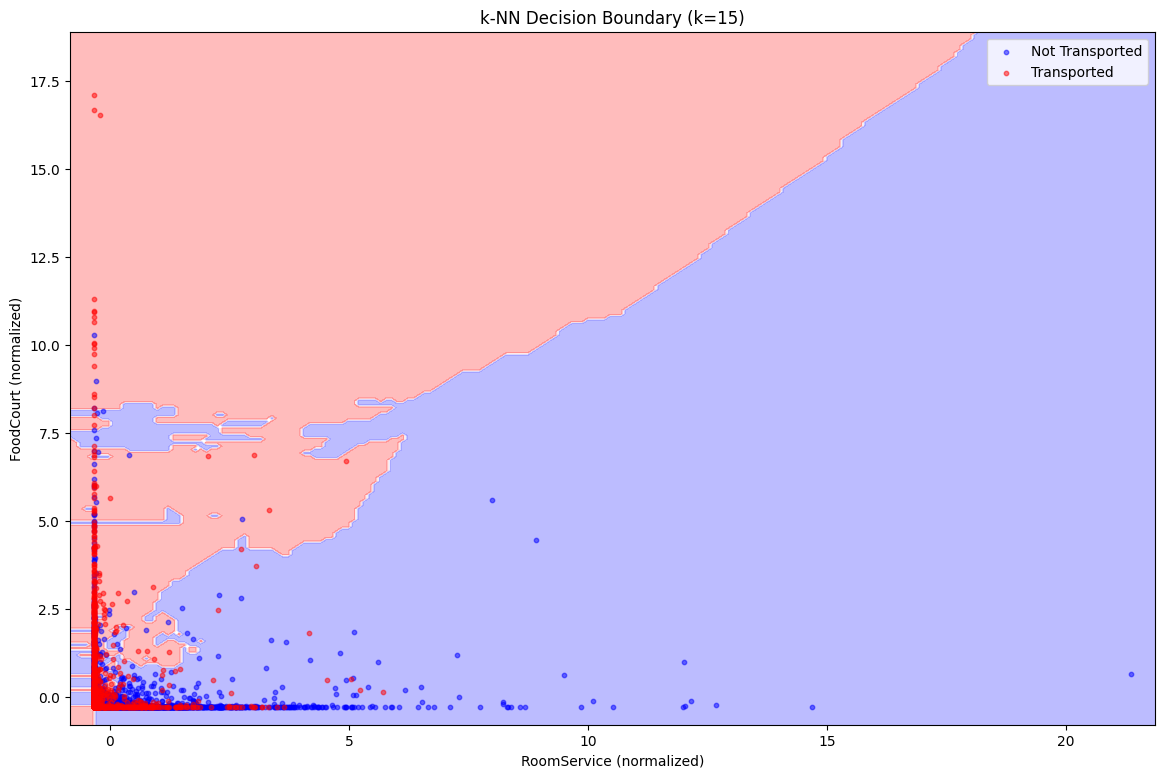

In [19]:
import matplotlib.pyplot as plt

x_min = inputs[:, 0].min() - 0.5
x_max = inputs[:, 0].max() + 0.5
y_min = inputs[:, 1].min() - 0.5
y_max = inputs[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_data = {'x': grid_points, 'y': None}
Z = np.array(knn.predict(grid_data, verbose=False)).reshape(xx.shape)

X_train = inputs[train_indxs]
y_train = labels[train_indxs].flatten()

plt.figure(figsize=(14, 9))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', label='Not Transported', alpha=0.5, s=10)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='red', label='Transported', alpha=0.5, s=10)
plt.xlabel('RoomService (normalized)')
plt.ylabel('FoodCourt (normalized)')
plt.title('k-NN Decision Boundary (k=15)')
plt.legend()
plt.show()